In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from zoneinfo import ZoneInfo

In [2]:
#loading dataset
df = pd.read_csv("C:/Users/yashr/Desktop/eve5/google_play_store_dataset.csv")

print(df.shape)
df.head()

(10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
print(df.columns)

df[['Category',
    'Rating',
    'Reviews',
    'Size',
    'Installs',
    'Last Updated']].head()

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')


,Category,Rating,Reviews,Size,Installs,Last Updated
0,ART_AND_DESIGN,4.1,159,19M,"10,000+","January 7, 2018"
1,ART_AND_DESIGN,3.9,967,14M,"500,000+","January 15, 2018"
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+","August 1, 2018"
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+","June 8, 2018"
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+","June 20, 2018"


In [4]:
#Cleaning rating
df['Rating'] = pd.to_numeric(
    df['Rating'],
    errors='coerce'
)

In [5]:
#Cleaning reviews
df['Reviews'] = pd.to_numeric(
    df['Reviews'],
    errors='coerce'
)

In [6]:
#Cleaning installs
df['Installs'] = (
    df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

df['Installs'] = pd.to_numeric(
    df['Installs'],
    errors='coerce'
)

In [7]:
#Cleaning size
def convert_size(size):

    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == 'Varies with device':
        return np.nan

    if 'M' in size:
        return float(size.replace('M', ''))

    if 'k' in size:
        return float(size.replace('k', '')) / 1024

    return np.nan


df['Size_MB'] = df['Size'].apply(convert_size)

In [8]:
#Cleaning last updated
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

In [9]:
#Applying filters
filtered_df = df[
    (df['Rating'] >= 4.0) &
    (df['Size_MB'] >= 10) &
    (df['Last Updated'].dt.month == 1)
].copy()

print("Filtered Rows:", len(filtered_df))

Filtered Rows: 131


In [10]:
#Aggregating category metrics
category_summary = (
    filtered_df
    .groupby('Category')
    .agg({
        'Rating': 'mean',
        'Reviews': 'sum',
        'Installs': 'sum'
    })
    .reset_index()
)

category_summary.columns = [
    'Category',
    'AvgRating',
    'TotalReviews',
    'TotalInstalls'
]

category_summary.head()

,Category,AvgRating,TotalReviews,TotalInstalls
0,ART_AND_DESIGN,4.166667,1200.0,120000.0
1,BOOKS_AND_REFERENCE,4.600000,33.0,1000.0
2,BUSINESS,4.900000,18.0,1200.0
3,COMMUNICATION,4.200000,15287.0,1000000.0
4,EDUCATION,4.400000,57645.0,2000000.0


In [11]:
#Top 10 Categories by Installs
top10 = (
    category_summary
    .sort_values(
        by='TotalInstalls',
        ascending=False
    )
    .head(10)
)

top10

,Category,AvgRating,TotalReviews,TotalInstalls
7,FAMILY,4.395455,4544623.0,182494820.0
19,SPORTS,4.342857,1982017.0,120511000.0
10,GAME,4.313333,2397589.0,115691000.0
5,ENTERTAINMENT,4.250000,1238948.0,51000000.0
14,PERSONALIZATION,4.475000,155996.0,15060000.0
15,PHOTOGRAPHY,4.150000,563720.0,10500000.0
11,LIFESTYLE,4.380000,42809.0,5071000.0
4,EDUCATION,4.400000,57645.0,2000000.0
17,SHOPPING,4.200000,19950.0,2000000.0
20,TOOLS,4.200000,8010.0,1010000.0


In [12]:
#Check IST time
def is_chart_visible():

    ist_now = datetime.now(
        ZoneInfo("Asia/Kolkata")
    )

    current_hour = ist_now.hour

    return 15 <= current_hour < 17

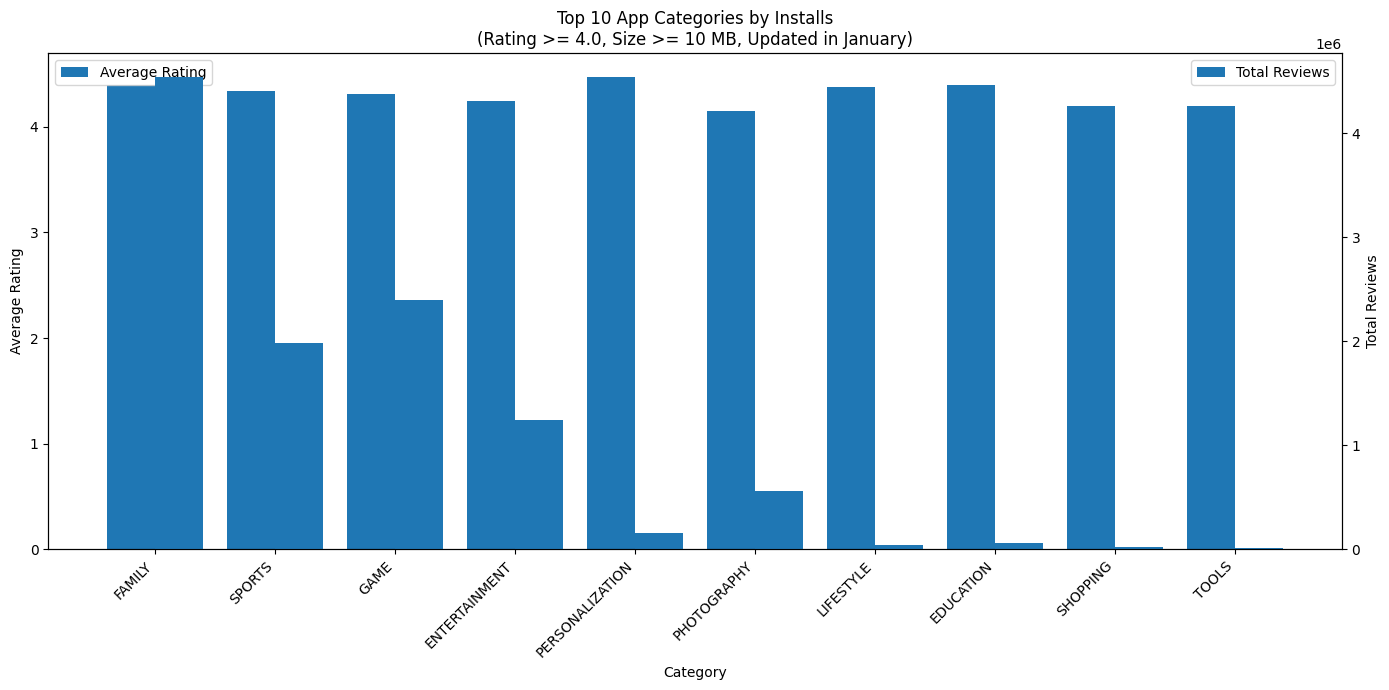

In [15]:
# Creating Grouped Bar Chart
if True:

    x = np.arange(len(top10))

    width = 0.4

    fig, ax1 = plt.subplots(
        figsize=(14,7)
    )

    rating_bars = ax1.bar(
        x - width/2,
        top10['AvgRating'],
        width,
        label='Average Rating'
    )

    ax2 = ax1.twinx()

    review_bars = ax2.bar(
        x + width/2,
        top10['TotalReviews'],
        width,
        label='Total Reviews'
    )

    ax1.set_xlabel('Category')
    ax1.set_ylabel('Average Rating')
    ax2.set_ylabel('Total Reviews')

    ax1.set_xticks(x)

    ax1.set_xticklabels(
        top10['Category'],
        rotation=45,
        ha='right'
    )

    plt.title(
        'Top 10 App Categories by Installs\n'
        '(Rating >= 4.0, Size >= 10 MB, Updated in January)'
    )

    ax1.legend(
        loc='upper left'
    )

    ax2.legend(
        loc='upper right'
    )

    plt.tight_layout()

    plt.show()

else:

    print(
        "Chart hidden.\n"
        "Available only between "
        "3 PM IST and 5 PM IST."
    )

In [14]:
#Show Current IST Time
ist_now = datetime.now(
    ZoneInfo("Asia/Kolkata")
)

print(
    "Current IST Time:",
    ist_now.strftime("%d-%m-%Y %H:%M:%S")
)

Current IST Time: 23-06-2026 11:42:07
